##Create a NN Layers with ReLU and SoftMax Activation function

Create spiral dataset

In [1]:
!pip install nnfs

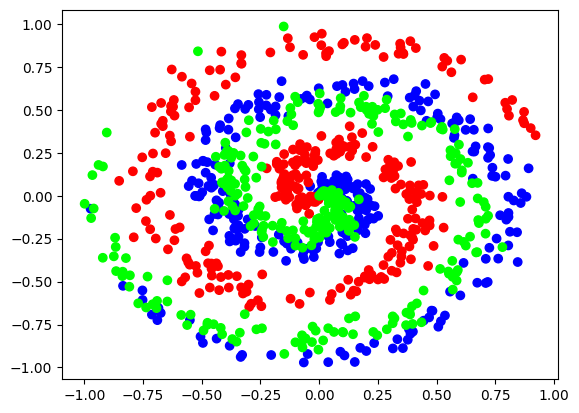

In [2]:
import nnfs
from nnfs.datasets import spiral_data
nnfs.init()
import numpy as np
import matplotlib.pyplot as plt

X,y = spiral_data(samples=300,classes=3)
plt.scatter(X[:,0],X[:,1], c=y, cmap='brg')
plt.show()

Create NN dense layer class

In [3]:
class Layer_Dense:
  def __init__(self, n_inputs, n_neurons):
    self.weights = 0.01 * np.random.randn(n_inputs,n_neurons)
    self.baises = np.zeros((1,n_neurons))

  def forward_pass(self, input):
    self.output = np.dot(input,self.weights)+self.baises

Create ReLU Activation Function Class

In [4]:
class Activation_ReLU:
  def forward_relu(self, inputs):
    self.relu_output = np.maximum(0,inputs)


Create Softmax Activation Function Class

In [5]:
class Activation_Softmax:
  def forward_softmax(self, inputs):
    exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
    probabilities = exp_values/np.sum(exp_values, axis=1, keepdims=True)
    self.softmax_output = probabilities

Forward Pass (Without Loss)

In [6]:
X,y = spiral_data(samples=300, classes=3)

dense1 = Layer_Dense(2, 3)
activation1 = Activation_ReLU()

dense2 = Layer_Dense(3,3)
activation2 = Activation_Softmax()

dense1.forward_pass(X)
activation1.forward_relu(dense1.output)

dense2.forward_pass(activation1.relu_output)
activation2.forward_softmax(dense2.output)

print(activation2.softmax_output[:5])

[[0.33333334 0.33333334 0.33333334]
 [0.3333332  0.33333337 0.33333337]
 [0.333333   0.33333355 0.33333343]
 [0.3333328  0.33333364 0.33333352]
 [0.33333284 0.33333364 0.33333352]]


Common Loss class

In [7]:
class Loss:
 def calculate(self, output, y):
  sample_losses = self.forward(output, y)
  data_loss = np.mean(sample_losses)
  return data_loss

Cross Entropy loss

In [8]:
class Loss_CategoricalCrossentropy(Loss):
 def forward(self, y_pred, y_true):
  samples = len(y_pred)
  y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)
  # Probabilities for target values -
  # only if categorical labels
  if len(y_true.shape) == 1:
   correct_confidences = y_pred_clipped[
   range(samples),
   y_true
   ]
  # Mask values - only for one-hot encoded labels
  elif len(y_true.shape) == 2:
   correct_confidences = np.sum(
   y_pred_clipped*y_true,
   axis=1
   )
 # Losses
  negative_log_likelihoods = -np.log(correct_confidences)
  return negative_log_likelihoods

In [15]:
# Create dataset
X, y = spiral_data(samples=100, classes=3)

# Create Dense layer with 2 input features and 3 output values
dense1 = Layer_Dense(2, 3)

# Create ReLU activation
activation1 = Activation_ReLU()

# Create second Dense layer
dense2 = Layer_Dense(3, 3)

# Create Softmax activation
activation2 = Activation_Softmax()

# Create loss function
loss_function = Loss_CategoricalCrossentropy()

# Forward pass through first dense layer
dense1.forward_pass(X)

# Forward pass through ReLU activation
activation1.forward_relu(dense1.output)

# Forward pass through second dense layer
dense2.forward_pass(activation1.relu_output)

# Forward pass through Softmax activation
activation2.forward_softmax(dense2.output)

# Print first 5 outputs
print(activation2.softmax_output[:5])

# Calculate loss
loss = loss_function.calculate(activation2.softmax_output, y)

# Print loss
print('loss:', loss)

# Calculate accuracy
predictions = np.argmax(activation2.softmax_output, axis=1)

if len(y.shape) == 2:
    y = np.argmax(y, axis=1)

accuracy = np.mean(predictions == y)

# Print accuracy
print('acc:', accuracy)

[[0.33333334 0.33333334 0.33333334]
 [0.33333334 0.3333335  0.33333316]
 [0.33333346 0.33333406 0.33333248]
 [0.33333343 0.33333385 0.33333272]
 [0.33333334 0.33333477 0.3333319 ]]
loss: 1.0986161
acc: 0.33
